# 🧩 02 — Feature Engineering Quality Check

This notebook verifies whether the feature-engineered Taiwan air quality dataset
(e.g., Taiwan.csv or per-county files) meets all feature integrity and consistency standards
before model training.

## 🧠 01 — Notebook Metadata
Basic setup information and environment initialization for this analysis.

In [1]:
import pandas as pd
from src.modeling.train_baseline import load_cleaned_data
from src.features.feature_engineering import (
    clip_pollutants,
    add_rolling_features,
    handle_outliers_iqr,
    log_transform_features,
)
import matplotlib.pyplot as plt
import seaborn as sns

## 🧱 02 — Load Processed Data

Load the cleaned dataset using load_cleaned_data and check:

- File `path` and `size`

- `Shape` and column structure

- Preview first few rows

In [2]:
df = load_cleaned_data("Taiwan")

📂 Loading CSV: C:\Users\dinni\OneDrive\桌面\air_pollution\data\processed\Taiwan.csv
✅ Read CSV successfully! Shape: (5823862, 25)


In [3]:
df = clip_pollutants(df)

✅ The pollutants limit has been set.


In [4]:
df = handle_outliers_iqr(df)

✅ IQR has been set.


In [5]:
df = add_rolling_features(df)

⚠️ Skipping nox due to NO + NO2 already exist.
✅ Rolling features added.


In [6]:
df = log_transform_features(df)

✅ Pollutants skewes has been smoothed.


In [7]:
df.shape

(5823862, 38)

In [8]:
df.dtypes

date                datetime64[ns]
sitename                    object
county                      object
aqi                        float64
status                      object
so2                        float64
co                         float64
o3                         float64
o3_8hr                     float64
pm10                       float64
pm2.5                      float64
no2                        float64
no                         float64
windspeed                  float64
winddirec                  float64
co_8hr                     float64
longitude                  float64
latitude                   float64
year                         int64
month                        int64
day                          int64
weekday                      int64
hour                         int64
season                      object
so2_rolling_3d             float64
so2_rolling_7d             float64
co_rolling_3d              float64
co_rolling_7d              float64
o3_rolling_3d       

In [9]:
df.head()

,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
0,2024-08-31 23:00:00,Hukou,Hsinchu_County,62.0,Moderate,0.641854,0.157004,3.583519,40.2,2.944439,...,35.0,35.0,18.0,18.0,17.0,17.0,2.3,2.3,0.3,0.3
54,2024-08-31 23:00:00,Magong,Penghu_County,74.0,Moderate,0.916291,0.207014,4.082609,62.8,2.890372,...,58.3,58.3,17.0,17.0,19.0,19.0,1.0,1.0,1.7,1.7
62,2024-08-31 23:00:00,Pingtung (Liuqiu),Pingtung_County,43.0,Good,0.336472,0.165514,3.618993,42.2,3.091042,...,36.3,36.3,21.0,21.0,9.0,9.0,3.8,3.8,0.3,0.3
61,2024-08-31 23:00:00,Tainan (Madou),Tainan_City,41.0,Good,0.530628,0.231112,3.173878,38.5,2.944439,...,22.9,22.9,18.0,18.0,7.0,7.0,12.5,12.5,1.1,1.1
60,2024-08-31 23:00:00,Kaohsiung (Hunei),Kaohsiung_City,37.0,Good,0.916291,0.165514,3.555348,40.8,2.639057,...,34.0,34.0,13.0,13.0,5.0,5.0,4.5,4.5,1.3,1.3


## 🕒 03 — Time Features Validation

Verify that all time-based columns were generated correctly during feature engineering:

- `year`, `month`, `day`, `weekday`, `hour`

- `season` classification

- Reasonable numeric ranges and no missing values

In [10]:
df[["year", "month", "day", "weekday", "hour"]].nunique()

year        9
month      12
day        31
weekday     7
hour       24
dtype: int64

In [11]:
df["season"].value_counts()

season
Spring    1605767
Winter    1512105
Summer    1472136
Autumn    1233854
Name: count, dtype: int64

In [12]:
df[["year", "month", "day", "weekday", "hour", "season"]].isna().any()

year       False
month      False
day        False
weekday    False
hour       False
season     False
dtype: bool

## 📈 04 — Rolling Features Validation

Check that rolling mean features (3-day, 7-day, etc.) exist and behave as expected:

- Verify columns like `pm2.5_rolling_3d`, `pm2.5_rolling_7d`, `co_rolling_3d`

- Inspect descriptive statistics

- Visualize trend smoothing over time

In [13]:
[col for col in df.columns if "rolling" in col]

['so2_rolling_3d',
 'so2_rolling_7d',
 'co_rolling_3d',
 'co_rolling_7d',
 'o3_rolling_3d',
 'o3_rolling_7d',
 'pm10_rolling_3d',
 'pm10_rolling_7d',
 'pm2.5_rolling_3d',
 'pm2.5_rolling_7d',
 'no2_rolling_3d',
 'no2_rolling_7d',
 'no_rolling_3d',
 'no_rolling_7d']

In [14]:
df[["pm2.5", "pm2.5_rolling_3d", "pm2.5_rolling_7d"]].describe()

,pm2.5,pm2.5_rolling_3d,pm2.5_rolling_7d
count,5.823791e+06,5.823791e+06,5.823791e+06
mean,2.630785e+00,1.634142e+01,1.634133e+01
std,7.189771e-01,1.054481e+01,1.017262e+01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.197225e+00,8.333333e+00,8.571429e+00
50%,2.708050e+00,1.366667e+01,1.371429e+01
75%,3.135494e+00,2.233333e+01,2.214286e+01
max,3.784190e+00,4.300000e+01,4.300000e+01


Text(0.5, 1.0, 'Rolling Mean vs Raw PM2.5')

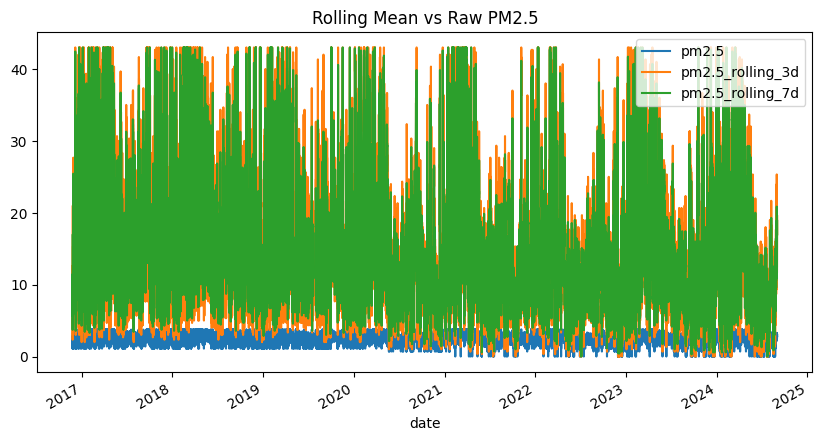

In [15]:
site_df = df[df["sitename"] == "Taoyuan"].set_index("date")
site_df[["pm2.5", "pm2.5_rolling_3d", "pm2.5_rolling_7d"]].plot(figsize=(10, 5))
plt.title("Rolling Mean vs Raw PM2.5")

## 🔗 05 — Feature Correlation Analysis

Assess potential multicollinearity among pollutant and rolling features:

- Compute correlation matrix (`df.corr()`)

- Visualize with heatmap (`sns.heatmap()`)

- Identify highly correlated pairs (>0.95)

In [16]:
corr = df.corr(numeric_only=True)
corr

,aqi,so2,co,o3,o3_8hr,pm10,pm2.5,no2,no,windspeed,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
aqi,1.000000,0.351343,0.472550,0.183694,0.349745,0.709597,0.764338,0.363746,0.027262,-0.024526,...,0.284731,0.279577,0.789544,0.769263,0.854688,0.831329,0.359040,0.359568,0.022968,0.013554
so2,0.351343,1.000000,0.366251,0.013872,0.029017,0.407709,0.395587,0.421339,0.261543,-0.002024,...,0.081481,0.084264,0.413527,0.400095,0.401830,0.388645,0.381295,0.357865,0.223419,0.196729
co,0.472550,0.366251,1.000000,-0.189551,-0.043490,0.440401,0.499451,0.782246,0.490671,-0.219665,...,-0.091109,-0.038707,0.465439,0.447373,0.532090,0.516436,0.799089,0.730099,0.519265,0.472487
o3,0.183694,0.013872,-0.189551,1.000000,0.704192,0.104891,0.108951,-0.287488,-0.347631,0.360539,...,0.871899,0.723461,0.125587,0.127187,0.085073,0.082658,-0.303229,-0.220567,-0.436487,-0.466582
o3_8hr,0.349745,0.029017,-0.043490,0.704192,1.000000,0.217909,0.209794,-0.129798,-0.394621,0.249253,...,0.649386,0.488108,0.241590,0.235295,0.193740,0.199250,-0.112814,-0.070820,-0.426665,-0.440394
pm10,0.709597,0.407709,0.440401,0.104891,0.217909,1.000000,0.778332,0.407639,0.114429,0.007227,...,0.203211,0.211164,0.888791,0.845470,0.768032,0.747811,0.369139,0.356855,0.099474,0.074080
pm2.5,0.764338,0.395587,0.499451,0.108951,0.209794,0.778332,1.000000,0.450287,0.106202,-0.067653,...,0.203268,0.215349,0.751388,0.727823,0.874384,0.828347,0.404442,0.391119,0.096828,0.081887
no2,0.363746,0.421339,0.782246,-0.287488,-0.129798,0.407639,0.450287,1.000000,0.520001,-0.296322,...,-0.227224,-0.190830,0.396936,0.382125,0.446087,0.436800,0.898342,0.828141,0.527409,0.501990
no,0.027262,0.261543,0.490671,-0.347631,-0.394621,0.114429,0.106202,0.520001,1.000000,-0.114734,...,-0.222427,-0.123171,0.093787,0.083654,0.097918,0.087209,0.513879,0.457964,0.901558,0.765259
windspeed,-0.024526,-0.002024,-0.219665,0.360539,0.249253,0.007227,-0.067653,-0.296322,-0.114734,1.000000,...,0.357826,0.327029,0.008614,0.001156,-0.095862,-0.103935,-0.272888,-0.253000,-0.159551,-0.202341


<Axes: >

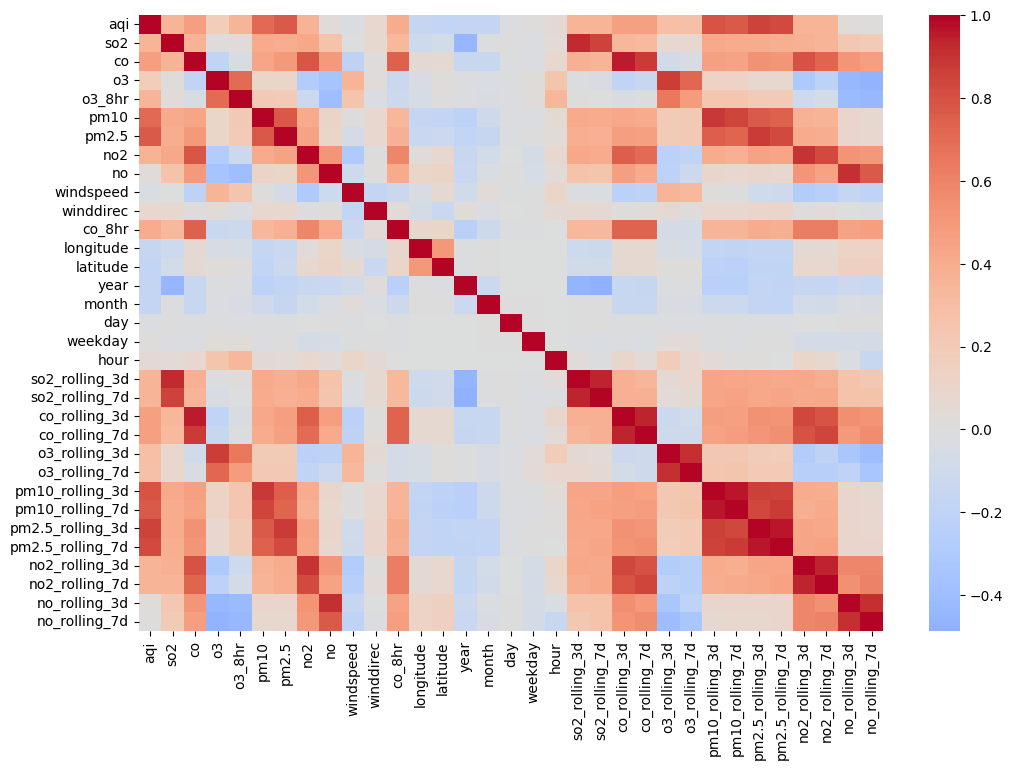

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)

## 📊 06 — Feature Distribution & Outliers

Evaluate statistical distributions for numerical features:

- Use `df.describe()` for summary stats

- Draw `histograms` or `boxplots` for pollutants

- Check for unrealistic outliers (e.g., negative or extreme pollution values)

In [18]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,5823862,2020-11-26 06:17:31.644631808,2016-11-25 13:00:00,2019-02-09 20:00:00,2021-02-02 11:00:00,2022-09-12 13:00:00,2024-08-31 23:00:00,NaN
aqi,5823862.0,54.230266,0.0,32.0,47.0,70.0,500.0,29.788731
so2,5823841.0,0.980554,0.0,0.693147,0.993252,1.252763,1.7492,0.400362
co,5823841.0,0.269706,0.0,0.173953,0.24686,0.34359,0.553885,0.123782
o3,5823841.0,3.224398,0.0,2.833213,3.367296,3.751854,4.394449,0.733745
o3_8hr,5823841.0,30.139134,-1.0,18.0,28.6,40.0,135.8,15.783429
pm10,5823607.0,3.341305,0.0,2.944439,3.401197,3.828641,4.460144,0.677475
pm2.5,5823791.0,2.630785,0.0,2.197225,2.70805,3.135494,3.78419,0.718977
no2,5823837.0,2.261632,0.0,1.808289,2.312535,2.772589,3.429137,0.693027
no,5823837.0,0.960631,0.0,0.587787,0.875469,1.308333,1.879465,0.520535


array([[<Axes: title={'center': 'pm2.5'}>,
        <Axes: title={'center': 'pm10'}>,
        <Axes: title={'center': 'so2'}>],
       [<Axes: title={'center': 'co'}>, <Axes: title={'center': 'o3'}>,
        <Axes: title={'center': 'no'}>],
       [<Axes: title={'center': 'no2'}>, <Axes: >, <Axes: >]],
      dtype=object)

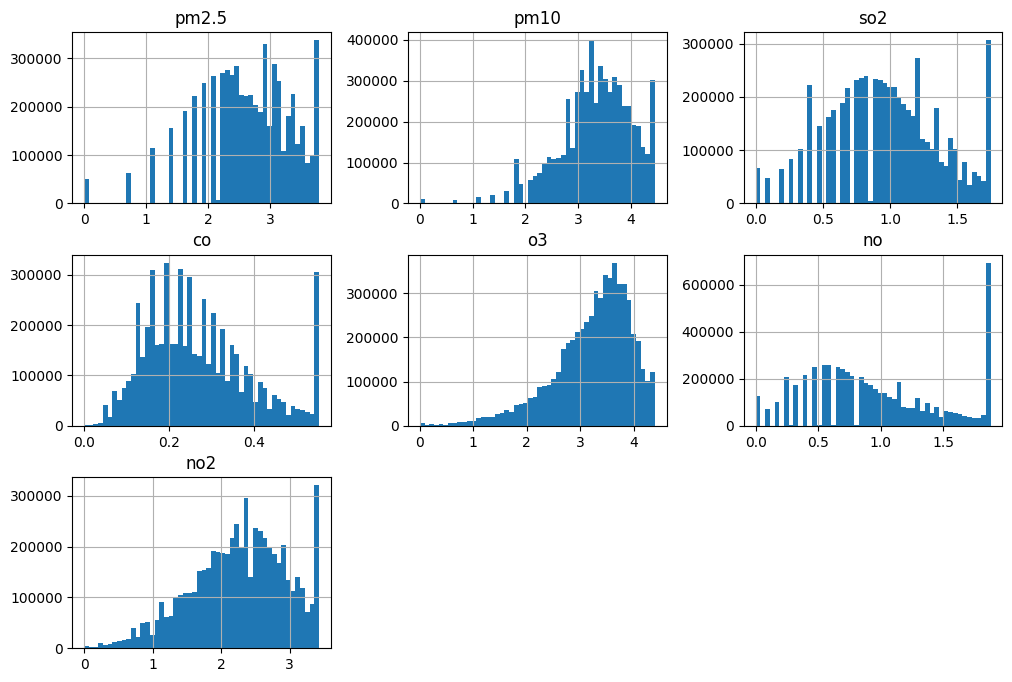

In [20]:
cols = ["pm2.5", "pm10", "so2", "co", "o3", "no", "no2"]
for c in cols:
    if c in df.columns:
        df[c] = df[c].clip(lower=0, upper=1000)

df[cols].hist(bins=50, figsize=(12, 8))

<Axes: xlabel='season', ylabel='pm2.5'>

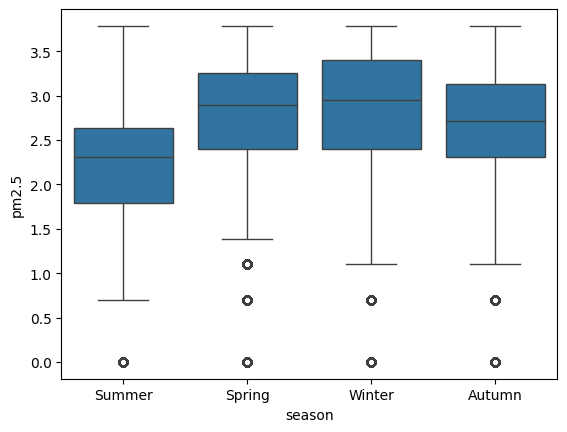

In [21]:
sns.boxplot(data=df, x="season", y="pm2.5")

## ⚙️ 07 — Missing Values & Data Types

Confirm that all features have appropriate data types and no excessive missing values:

- Missing value ratio < 1% for key pollutants

- `object` columns limited to categorical features (`county`, `sitename`, `season`)

- All numeric features are `float64` or `int64`

In [22]:
(df.isna().mean()*100).sort_values(ascending=False)

status              1.595110
pm10                0.004379
pm10_rolling_7d     0.004379
pm10_rolling_3d     0.004379
pm2.5               0.001219
pm2.5_rolling_3d    0.001219
pm2.5_rolling_7d    0.001219
no2_rolling_3d      0.000429
no_rolling_3d       0.000429
no_rolling_7d       0.000429
no2                 0.000429
no2_rolling_7d      0.000429
no                  0.000429
so2                 0.000361
co_rolling_3d       0.000361
co_rolling_7d       0.000361
o3_rolling_7d       0.000361
o3_rolling_3d       0.000361
o3_8hr              0.000361
o3                  0.000361
co                  0.000361
co_8hr              0.000361
so2_rolling_3d      0.000361
so2_rolling_7d      0.000361
date                0.000000
sitename            0.000000
county              0.000000
aqi                 0.000000
winddirec           0.000000
windspeed           0.000000
weekday             0.000000
day                 0.000000
month               0.000000
year                0.000000
latitude      

In [23]:
df.dtypes.value_counts()

float64           28
int64              5
object             4
datetime64[ns]     1
Name: count, dtype: int64

In [24]:
df.select_dtypes(include="object").columns

Index(['sitename', 'county', 'status', 'season'], dtype='object')

In [25]:
df.select_dtypes(include=["float64", "int64"]).columns

Index(['aqi', 'so2', 'co', 'o3', 'o3_8hr', 'pm10', 'pm2.5', 'no2', 'no',
       'windspeed', 'winddirec', 'co_8hr', 'longitude', 'latitude', 'year',
       'month', 'day', 'weekday', 'hour', 'so2_rolling_3d', 'so2_rolling_7d',
       'co_rolling_3d', 'co_rolling_7d', 'o3_rolling_3d', 'o3_rolling_7d',
       'pm10_rolling_3d', 'pm10_rolling_7d', 'pm2.5_rolling_3d',
       'pm2.5_rolling_7d', 'no2_rolling_3d', 'no2_rolling_7d', 'no_rolling_3d',
       'no_rolling_7d'],
      dtype='object')

## 🌡️ 08 — Feature–Target Relationship

Explore linear correlation between each feature and `AQI`:

- Compute correlation coefficients

- Identify top features most predictive of `AQI`

- Visualize top contributors with bar chart

In [26]:
corr = df.corr(numeric_only=True)
corr

,aqi,so2,co,o3,o3_8hr,pm10,pm2.5,no2,no,windspeed,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
aqi,1.000000,0.351343,0.472550,0.183694,0.349745,0.709597,0.764338,0.363746,0.027262,-0.024526,...,0.284731,0.279577,0.789544,0.769263,0.854688,0.831329,0.359040,0.359568,0.022968,0.013554
so2,0.351343,1.000000,0.366251,0.013872,0.029017,0.407709,0.395587,0.421339,0.261543,-0.002024,...,0.081481,0.084264,0.413527,0.400095,0.401830,0.388645,0.381295,0.357865,0.223419,0.196729
co,0.472550,0.366251,1.000000,-0.189551,-0.043490,0.440401,0.499451,0.782246,0.490671,-0.219665,...,-0.091109,-0.038707,0.465439,0.447373,0.532090,0.516436,0.799089,0.730099,0.519265,0.472487
o3,0.183694,0.013872,-0.189551,1.000000,0.704192,0.104891,0.108951,-0.287488,-0.347631,0.360539,...,0.871899,0.723461,0.125587,0.127187,0.085073,0.082658,-0.303229,-0.220567,-0.436487,-0.466582
o3_8hr,0.349745,0.029017,-0.043490,0.704192,1.000000,0.217909,0.209794,-0.129798,-0.394621,0.249253,...,0.649386,0.488108,0.241590,0.235295,0.193740,0.199250,-0.112814,-0.070820,-0.426665,-0.440394
pm10,0.709597,0.407709,0.440401,0.104891,0.217909,1.000000,0.778332,0.407639,0.114429,0.007227,...,0.203211,0.211164,0.888791,0.845470,0.768032,0.747811,0.369139,0.356855,0.099474,0.074080
pm2.5,0.764338,0.395587,0.499451,0.108951,0.209794,0.778332,1.000000,0.450287,0.106202,-0.067653,...,0.203268,0.215349,0.751388,0.727823,0.874384,0.828347,0.404442,0.391119,0.096828,0.081887
no2,0.363746,0.421339,0.782246,-0.287488,-0.129798,0.407639,0.450287,1.000000,0.520001,-0.296322,...,-0.227224,-0.190830,0.396936,0.382125,0.446087,0.436800,0.898342,0.828141,0.527409,0.501990
no,0.027262,0.261543,0.490671,-0.347631,-0.394621,0.114429,0.106202,0.520001,1.000000,-0.114734,...,-0.222427,-0.123171,0.093787,0.083654,0.097918,0.087209,0.513879,0.457964,0.901558,0.765259
windspeed,-0.024526,-0.002024,-0.219665,0.360539,0.249253,0.007227,-0.067653,-0.296322,-0.114734,1.000000,...,0.357826,0.327029,0.008614,0.001156,-0.095862,-0.103935,-0.272888,-0.253000,-0.159551,-0.202341


In [27]:
aqi_corr = corr["aqi"][1:].sort_values(ascending=False)
aqi_corr

pm2.5_rolling_3d    0.854688
pm2.5_rolling_7d    0.831329
pm10_rolling_3d     0.789544
pm10_rolling_7d     0.769263
pm2.5               0.764338
pm10                0.709597
co                  0.472550
co_rolling_3d       0.460793
co_rolling_7d       0.460645
co_8hr              0.404932
no2                 0.363746
no2_rolling_7d      0.359568
no2_rolling_3d      0.359040
so2_rolling_3d      0.356592
so2_rolling_7d      0.354086
so2                 0.351343
o3_8hr              0.349745
o3_rolling_3d       0.284731
o3_rolling_7d       0.279577
o3                  0.183694
winddirec           0.085855
hour                0.053540
no                  0.027262
no_rolling_3d       0.022968
no_rolling_7d       0.013554
weekday             0.013481
day                -0.018876
windspeed          -0.024526
longitude          -0.159978
year               -0.169650
month              -0.177495
latitude           -0.180691
Name: aqi, dtype: float64

<Axes: >

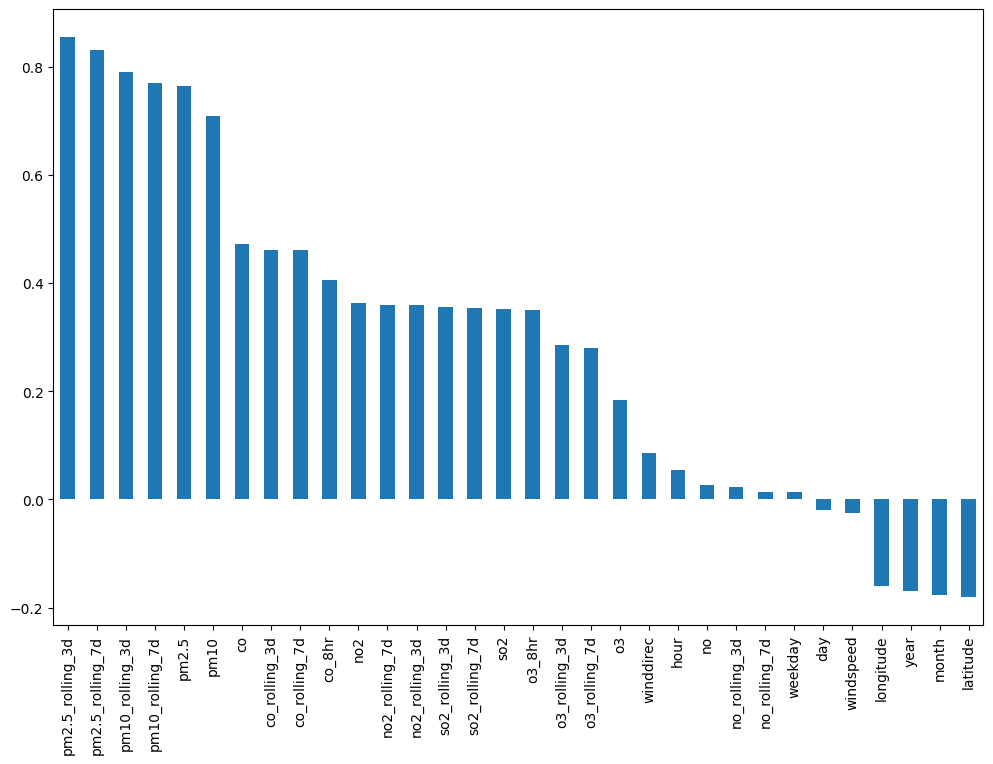

In [28]:
aqi_corr.plot(kind="bar",figsize=(12,8))

## ✅ 09 — Summary & Conclusions

Summarize the findings of the feature validation:

✅ Time features generated correctly

✅ Rolling features smoothed as expected

✅ No missing or misaligned data

⚠️ Some pollutant features highly correlated (expected)

✅ Dataset ready for baseline modeling